#Import Libraries

In [14]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

#Load Dataset

In [15]:
df = pd.read_csv("credit_risk_dataset.csv")

print(df.shape)
df.head()

(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


#Data Cleaning

In [16]:
# Handle missing values
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

# Check again
df.isnull().sum()

C:\Users\Hp\AppData\Local\Temp\ipykernel_48672\1692534083.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
C:\Users\Hp\AppData\Local\Temp\ipykernel_48672\1692534083.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

#Encode Categorical Variables

In [17]:
categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

#Define Features & Target

In [18]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

#Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Feature Scaling (for Logistic Regression)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#MODEL 1: Logistic Regression

In [21]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.86      0.95      0.91      5095
           1       0.72      0.47      0.57      1422

    accuracy                           0.84      6517
   macro avg       0.79      0.71      0.74      6517
weighted avg       0.83      0.84      0.83      6517



#MODEL 2: CatBoost (Powerful Model 🚀)

In [22]:
cat_model = CatBoostClassifier(verbose=0)

cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)

print("CatBoost Results:")
print(classification_report(y_test, y_pred_cat))

CatBoost Results:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5095
           1       0.98      0.72      0.83      1422

    accuracy                           0.94      6517
   macro avg       0.95      0.86      0.90      6517
weighted avg       0.94      0.94      0.93      6517



#BUSINESS COST OPTIMIZATION (CORE PART)

#Define Cost Function

In [23]:
# Define business costs
COST_FP = 1000   # Approving risky customer
COST_FN = 200    # Rejecting good customer

def calculate_cost(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    
    tn, fp, fn, tp = cm.ravel()
    
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    return total_cost

#Find Optimal Threshold

In [24]:
# Get probabilities
y_probs = cat_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)

costs = []

for t in thresholds:
    y_pred_thresh = (y_probs >= t).astype(int)
    cost = calculate_cost(y_test, y_pred_thresh)
    costs.append(cost)

# Best threshold
best_threshold = thresholds[np.argmin(costs)]

print("Best Threshold:", best_threshold)
print("Minimum Cost:", min(costs))

Best Threshold: 0.6599999999999997
Minimum Cost: 87000


#Plot Cost vs Threshold

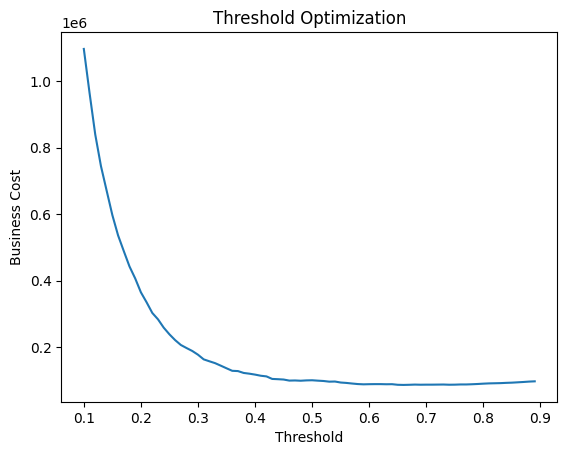

In [25]:
plt.plot(thresholds, costs)
plt.xlabel("Threshold")
plt.ylabel("Business Cost")
plt.title("Threshold Optimization")
plt.show()

#Final Model Evaluation (Optimized)

In [26]:
final_preds = (y_probs >= best_threshold).astype(int)

print("Final Optimized Model:")
print(classification_report(y_test, final_preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test, final_preds))

Final Optimized Model:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      5095
           1       1.00      0.70      0.83      1422

    accuracy                           0.94      6517
   macro avg       0.96      0.85      0.89      6517
weighted avg       0.94      0.94      0.93      6517

Confusion Matrix:
[[5092    3]
 [ 420 1002]]
